# Análisis de la Red Social YouTube Hispano

Este notebook realiza un análisis completo de la red social de YouTubers/streamers hispanos, siguiendo la metodología del curso de Redes Complejas.

In [469]:
# Importaciones
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from networkx.algorithms.community import louvain_communities, greedy_modularity_communities
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

## 1. Carga y descripción básica de la red

In [470]:
# Cargar el grafo desde GML
G = nx.read_gml('youtube-hispano.gml', label='label')

print(f"La red tiene {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas")
print(f"La red es: {'dirigida' if G.is_directed() else 'no dirigida'}")
print(f"La red es: {'ponderada' if nx.is_weighted(G) else 'no ponderada'}")
print()

# Mostrar nodos con su categoría
print("Nodos de la red:")
for node, data in G.nodes(data=True):
    print(f"{node:<25} -> Categoría: {data.get('category', 'N/A')}")

La red tiene 40 nodos y 71 aristas
La red es: no dirigida
La red es: no ponderada

Nodos de la red:
Ibai                      -> Categoría: Streamer
Auronplay                 -> Categoría: Streamer
Rubius                    -> Categoría: Streamer
IlloJuan                  -> Categoría: Streamer
ElXokas                   -> Categoría: Streamer
TheGrefg                  -> Categoría: Streamer
Willyrex                  -> Categoría: Gaming Clasico
Vegetta777                -> Categoría: Gaming Clasico
DjMaRiiO                  -> Categoría: Gaming Clasico
Alexelcapo                -> Categoría: Variety
BaityBait                 -> Categoría: Review
Joseju                    -> Categoría: Review
DayoScript                -> Categoría: Review
Nate Gentile              -> Categoría: Tech
SFDX Show                 -> Categoría: Tech
DotCSV                    -> Categoría: Tech
Jordi Wild                -> Categoría: Podcast
Tamayo                    -> Categoría: Investigacion
QuantumFracture

## 2. Métricas globales de la red

In [471]:
# Métricas globales
n = G.number_of_nodes()
m = G.number_of_edges()
grado_medio = 2 * m / float(n)
densidad = nx.density(G)
componentes = list(nx.connected_components(G))
transitivity = nx.transitivity(G)

print("RESUMEN DE MÉTRICAS GLOBALES")
print("-" * 50)
print(f"Número de nodos (N):          {n}")
print(f"Número de aristas (M):        {m}")
print(f"Grado medio <k>:              {grado_medio:.4f}")
print(f"Densidad:                     {densidad:.4f}")
print(f"Número de componentes:        {len(componentes)}")
print(f"Tamaños de componentes:       {sorted([len(c) for c in componentes], reverse=True)}")
print(f"Transitividad (clustering):   {transitivity:.4f}")

# Métricas de la componente gigante
GCC = G.subgraph(max(componentes, key=len)).copy()
print()
print(f"[Componente Gigante]")
print(f"Nodos en GCC:                 {GCC.number_of_nodes()}")
print(f"Aristas en GCC:               {GCC.number_of_edges()}")

if nx.is_connected(GCC):
    avg_path = nx.average_shortest_path_length(GCC)
    diametro = nx.diameter(GCC)
    print(f"Distancia media:              {avg_path:.4f}")
    print(f"Diámetro:                     {diametro}")
    if diametro <= 6:
        print(f"-- Se cumple el principio de los 6 grados de separación (diámetro={diametro})")
    else:
        print(f"-- No se cumple estrictamente el principio de los 6 grados de separación (diámetro={diametro})")

asortatividad = nx.degree_assortativity_coefficient(GCC)
print(f"Asortatividad:                {asortatividad:.4f}")
if asortatividad > 0:
    print("-- Asortativa: nodos de alto grado se conectan entre sí")
else:
    print("-- Disasortativa: nodos hub conectan con nodos periféricos")

RESUMEN DE MÉTRICAS GLOBALES
--------------------------------------------------
Número de nodos (N):          40
Número de aristas (M):        71
Grado medio <k>:              3.5500
Densidad:                     0.0910
Número de componentes:        1
Tamaños de componentes:       [40]
Transitividad (clustering):   0.3108

[Componente Gigante]
Nodos en GCC:                 40
Aristas en GCC:               71
Distancia media:              3.3679
Diámetro:                     7
-- No se cumple estrictamente el principio de los 6 grados de separación (diámetro=7)
Asortatividad:                0.0347
-- Asortativa: nodos de alto grado se conectan entre sí


## 3. Distribución de grados

In [472]:
# Distribución de grados
grados = [d for n, d in G.degree()]

print("Grado de cada nodo:")
for node, deg in sorted(G.degree(), key=lambda x: x[1], reverse=True):
    print(f"{node:<25} {deg:>3}")

print(f"Grado medio: {np.mean(grados):.4f}")
print(f"Grado máximo: {max(grados)}")
print(f"Grado mínimo: {min(grados)}")
print(f"Desviación estándar: {np.std(grados):.4f}")

Grado de cada nodo:
Ibai                       11
Rubius                      8
IlloJuan                    6
Willyrex                    6
Juan Guarnizo               6
TheGrefg                    5
Alexelcapo                  5
Jordi Wild                  5
Auronplay                   4
Vegetta777                  4
DjMaRiiO                    4
Nate Gentile                4
DotCSV                      4
aLexBY11                    4
Nil Ojeda                   4
ElXokas                     3
BaityBait                   3
Joseju                      3
SFDX Show                   3
QuantumFracture             3
Javier Santaolalla          3
La Gata de Schrodinger      3
Spursito                    3
Rivers                      3
Spreen                      3
Quackity                    3
Roier                       3
ElMariana                   3
Knekro                      3
DayoScript                  2
Tamayo                      2
Gerard Romero               2
AriGameplays        

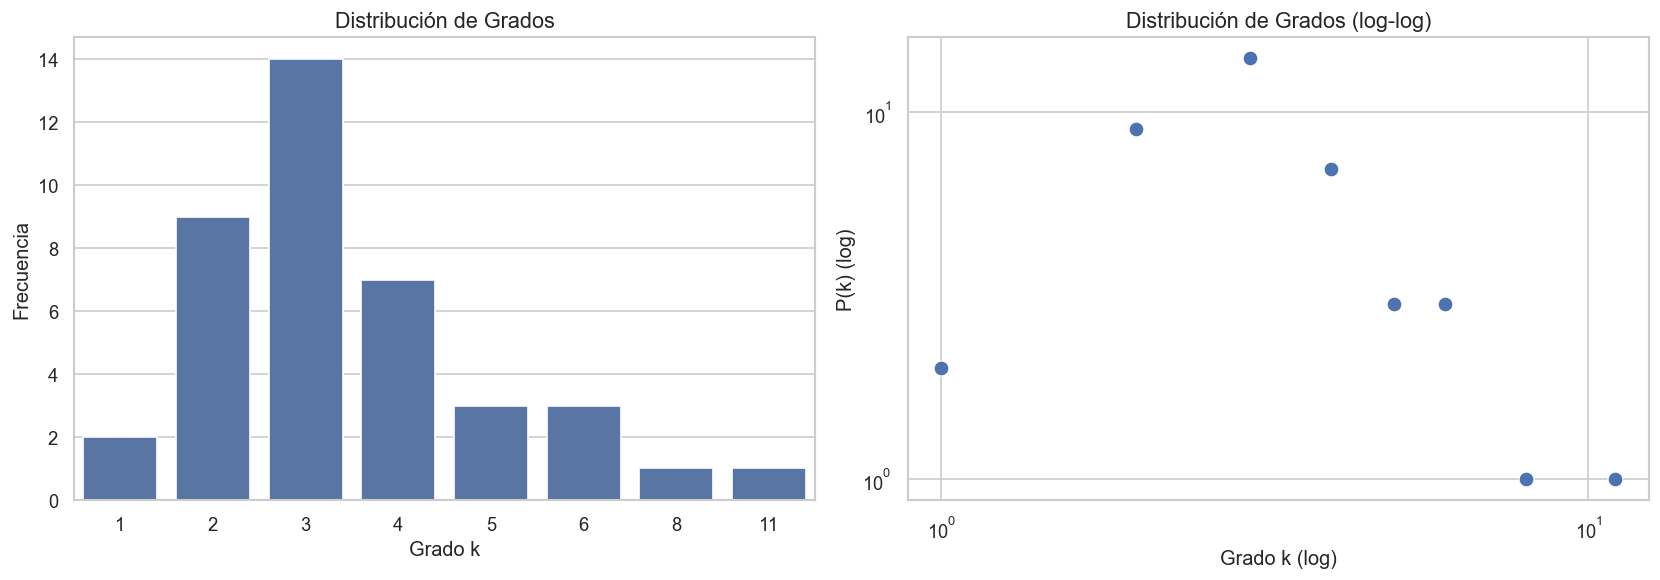

In [473]:
# Visualización distribución de grados
grados_ord = sorted(set(grados))
conteo = [grados.count(g) for g in grados_ord]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma normal
sns.countplot(x=grados, ax=axes[0])
axes[0].set_title("Distribución de Grados", fontsize=13)
axes[0].set_xlabel("Grado k")
axes[0].set_ylabel("Frecuencia")

# Log-log
axes[1].set_xscale("log")
axes[1].set_yscale("log")
sns.scatterplot(x=grados_ord, y=conteo, ax=axes[1], s=80)
axes[1].set_title("Distribución de Grados (log-log)", fontsize=13)
axes[1].set_xlabel("Grado k (log)")
axes[1].set_ylabel("P(k) (log)")

plt.tight_layout()
plt.savefig("distribucion_grados.png", bbox_inches="tight")
plt.show()

## 4. Medidas de centralidad

In [474]:
# Cálculo de todas las medidas de centralidad
# Degree centrality
degree_cent = nx.degree_centrality(G)

# Betweenness centrality
betweenness = nx.betweenness_centrality(G)

# Clustering
clustering = nx.clustering(G)

print("Medidas de centralidad calculadas:")
print(f"- Degree Centrality")
print(f"- Betweenness Centrality")
print(f"- Clustering Coefficient")

Medidas de centralidad calculadas:
- Degree Centrality
- Betweenness Centrality
- Clustering Coefficient


In [475]:
# Tabla resumen de centralidades
nodes_in_gcc = list(GCC.nodes())

df_centralidad = pd.DataFrame({
    "Nodo": list(G.nodes()),
    "Categoría": [G.nodes[n].get('category', 'N/A') for n in G.nodes()],
    "Grado": [G.degree(n) for n in G.nodes()],
    "Degree Cent.": [round(degree_cent.get(n, 0), 4) for n in G.nodes()],
    "Betweenness": [round(betweenness.get(n, 0), 4) for n in G.nodes()],
    "Clustering": [round(clustering.get(n, 0), 4) for n in G.nodes()],
})

df_centralidad = df_centralidad.sort_values("Betweenness", ascending=False).reset_index(drop=True)

print("TABLA DE CENTRALIDADES (ordenada por Betweenness):")
print(df_centralidad.to_string(index=False))

TABLA DE CENTRALIDADES (ordenada por Betweenness):
                  Nodo      Categoría  Grado  Degree Cent.  Betweenness  Clustering
                  Ibai       Streamer     11        0.2821       0.6090      0.1455
            Jordi Wild        Podcast      5        0.1282       0.3466      0.1000
              IlloJuan       Streamer      6        0.1538       0.2953      0.2667
                Rubius       Streamer      8        0.2051       0.2513      0.2143
            Alexelcapo        Variety      5        0.1282       0.1930      0.2000
             Nil Ojeda            IRL      4        0.1026       0.0999      0.3333
         Juan Guarnizo          LATAM      6        0.1538       0.0888      0.2667
              Willyrex Gaming Clasico      6        0.1538       0.0844      0.3333
          Nate Gentile           Tech      4        0.1026       0.0710      0.5000
                DotCSV           Tech      4        0.1026       0.0513      0.3333
              TheGrefg   

In [476]:
# Top 5 nodos por cada métrica
metricas = {
    "Degree Cent.": degree_cent,
    "Betweenness": betweenness,
    "Clustering": clustering
}

print("TOP 5 NODOS POR CADA MÉTRICA DE CENTRALIDAD")
print("-" * 60)
for nombre, metrica in metricas.items():
    top5 = sorted(metrica.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"{nombre}:")
    for i, (nodo, valor) in enumerate(top5, 1):
        cat = G.nodes[nodo].get('category', 'N/A')
        print(f"    {i}. {nodo:<25} {valor:.4f}  [{cat}]")

TOP 5 NODOS POR CADA MÉTRICA DE CENTRALIDAD
------------------------------------------------------------
Degree Cent.:
    1. Ibai                      0.2821  [Streamer]
    2. Rubius                    0.2051  [Streamer]
    3. IlloJuan                  0.1538  [Streamer]
    4. Willyrex                  0.1538  [Gaming Clasico]
    5. Juan Guarnizo             0.1538  [LATAM]
Betweenness:
    1. Ibai                      0.6090  [Streamer]
    2. Jordi Wild                0.3466  [Podcast]
    3. IlloJuan                  0.2953  [Streamer]
    4. Rubius                    0.2513  [Streamer]
    5. Alexelcapo                0.1930  [Variety]
Clustering:
    1. DayoScript                1.0000  [Review]
    2. AriGameplays              1.0000  [LATAM]
    3. Mangel                    1.0000  [Gaming Clasico]
    4. Misho                     1.0000  [IRL]
    5. Guanyar                   1.0000  [IRL]


## 5. Detección de comunidades

In [477]:
# Detección de comunidades con Louvain
comunidades_louvain = louvain_communities(G, seed=42)
comunidades_modularity = list(greedy_modularity_communities(G))

print(f"Louvain: {len(comunidades_louvain)} comunidades detectadas")
for i, com in enumerate(sorted(comunidades_louvain, key=len, reverse=True)):
    print(f"- Comunidad {i+1} ({len(com)} nodos): {sorted(com)}")

print()
mod_louvain = nx.community.modularity(G, comunidades_louvain)
print(f"Modularidad (Louvain):            {mod_louvain:.4f}")

mod_greedy = nx.community.modularity(G, comunidades_modularity)
print(f"Modularidad (Greedy Modularity):  {mod_greedy:.4f}")

Louvain: 5 comunidades detectadas
- Comunidad 1 (9 nodos): ['Alexelcapo', 'BaityBait', 'DayoScript', 'ElRichMC', 'ElXokas', 'IlloJuan', 'Joseju', 'Knekro', 'Masi']
- Comunidad 2 (9 nodos): ['Croma', 'DotCSV', 'Javier Santaolalla', 'Jordi Wild', 'La Gata de Schrodinger', 'Nate Gentile', 'QuantumFracture', 'SFDX Show', 'Tamayo']
- Comunidad 3 (8 nodos): ['AriGameplays', 'Auronplay', 'ElMariana', 'Juan Guarnizo', 'Quackity', 'Rivers', 'Roier', 'Spreen']
- Comunidad 4 (8 nodos): ['DjMaRiiO', 'Gerard Romero', 'Luzu', 'Mangel', 'Rubius', 'Vegetta777', 'Willyrex', 'aLexBY11']
- Comunidad 5 (6 nodos): ['Guanyar', 'Ibai', 'Misho', 'Nil Ojeda', 'Spursito', 'TheGrefg']

Modularidad (Louvain):            0.6019
Modularidad (Greedy Modularity):  0.5990


In [478]:
# Cliques en la red
cliques = list(nx.find_cliques(G))
cliques_grandes = [c for c in cliques if len(c) >= 3]

print(f"Total de cliques: {len(cliques)}")
print(f"Cliques de 3 o más nodos: {len(cliques_grandes)}")
print()
print("Cliques más grandes:")
for c in sorted(cliques_grandes, key=len, reverse=True)[:5]:
    print(f"- {c} (tamaño {len(c)})")

Total de cliques: 39
Cliques de 3 o más nodos: 26

Cliques más grandes:
- ['Quackity', 'Spreen', 'Roier'] (tamaño 3)
- ['SFDX Show', 'Nate Gentile', 'DotCSV'] (tamaño 3)
- ['SFDX Show', 'Nate Gentile', 'Croma'] (tamaño 3)
- ['Guanyar', 'Misho', 'Nil Ojeda'] (tamaño 3)
- ['Javier Santaolalla', 'La Gata de Schrodinger', 'QuantumFracture'] (tamaño 3)


## 6. Visualización de la red

In [479]:
# Paleta de colores por categoría
categorias = list(set(nx.get_node_attributes(G, "category").values()))
palette = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
    "#ff7f00", "#a65628", "#f781bf", "#999999",
    "#66c2a5", "#fc8d62", "#8da0cb"
]
color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(sorted(categorias))}

# Color por nodo
node_colors = [color_map[G.nodes[n]["category"]] for n in G.nodes()]

# Leyenda
legend_patches = [mpatches.Patch(color=color_map[cat], label=cat) for cat in sorted(categorias)]

print("Mapa de colores por categoría:")
for cat, col in color_map.items():
    print(f"- {cat:<25} -> {col}")

Mapa de colores por categoría:
- Ciencia                   -> #e41a1c
- Deportes                  -> #377eb8
- Gaming Clasico            -> #4daf4a
- IRL                       -> #984ea3
- Investigacion             -> #ff7f00
- LATAM                     -> #a65628
- Podcast                   -> #f781bf
- Review                    -> #999999
- Streamer                  -> #66c2a5
- Tech                      -> #fc8d62
- Variety                   -> #8da0cb


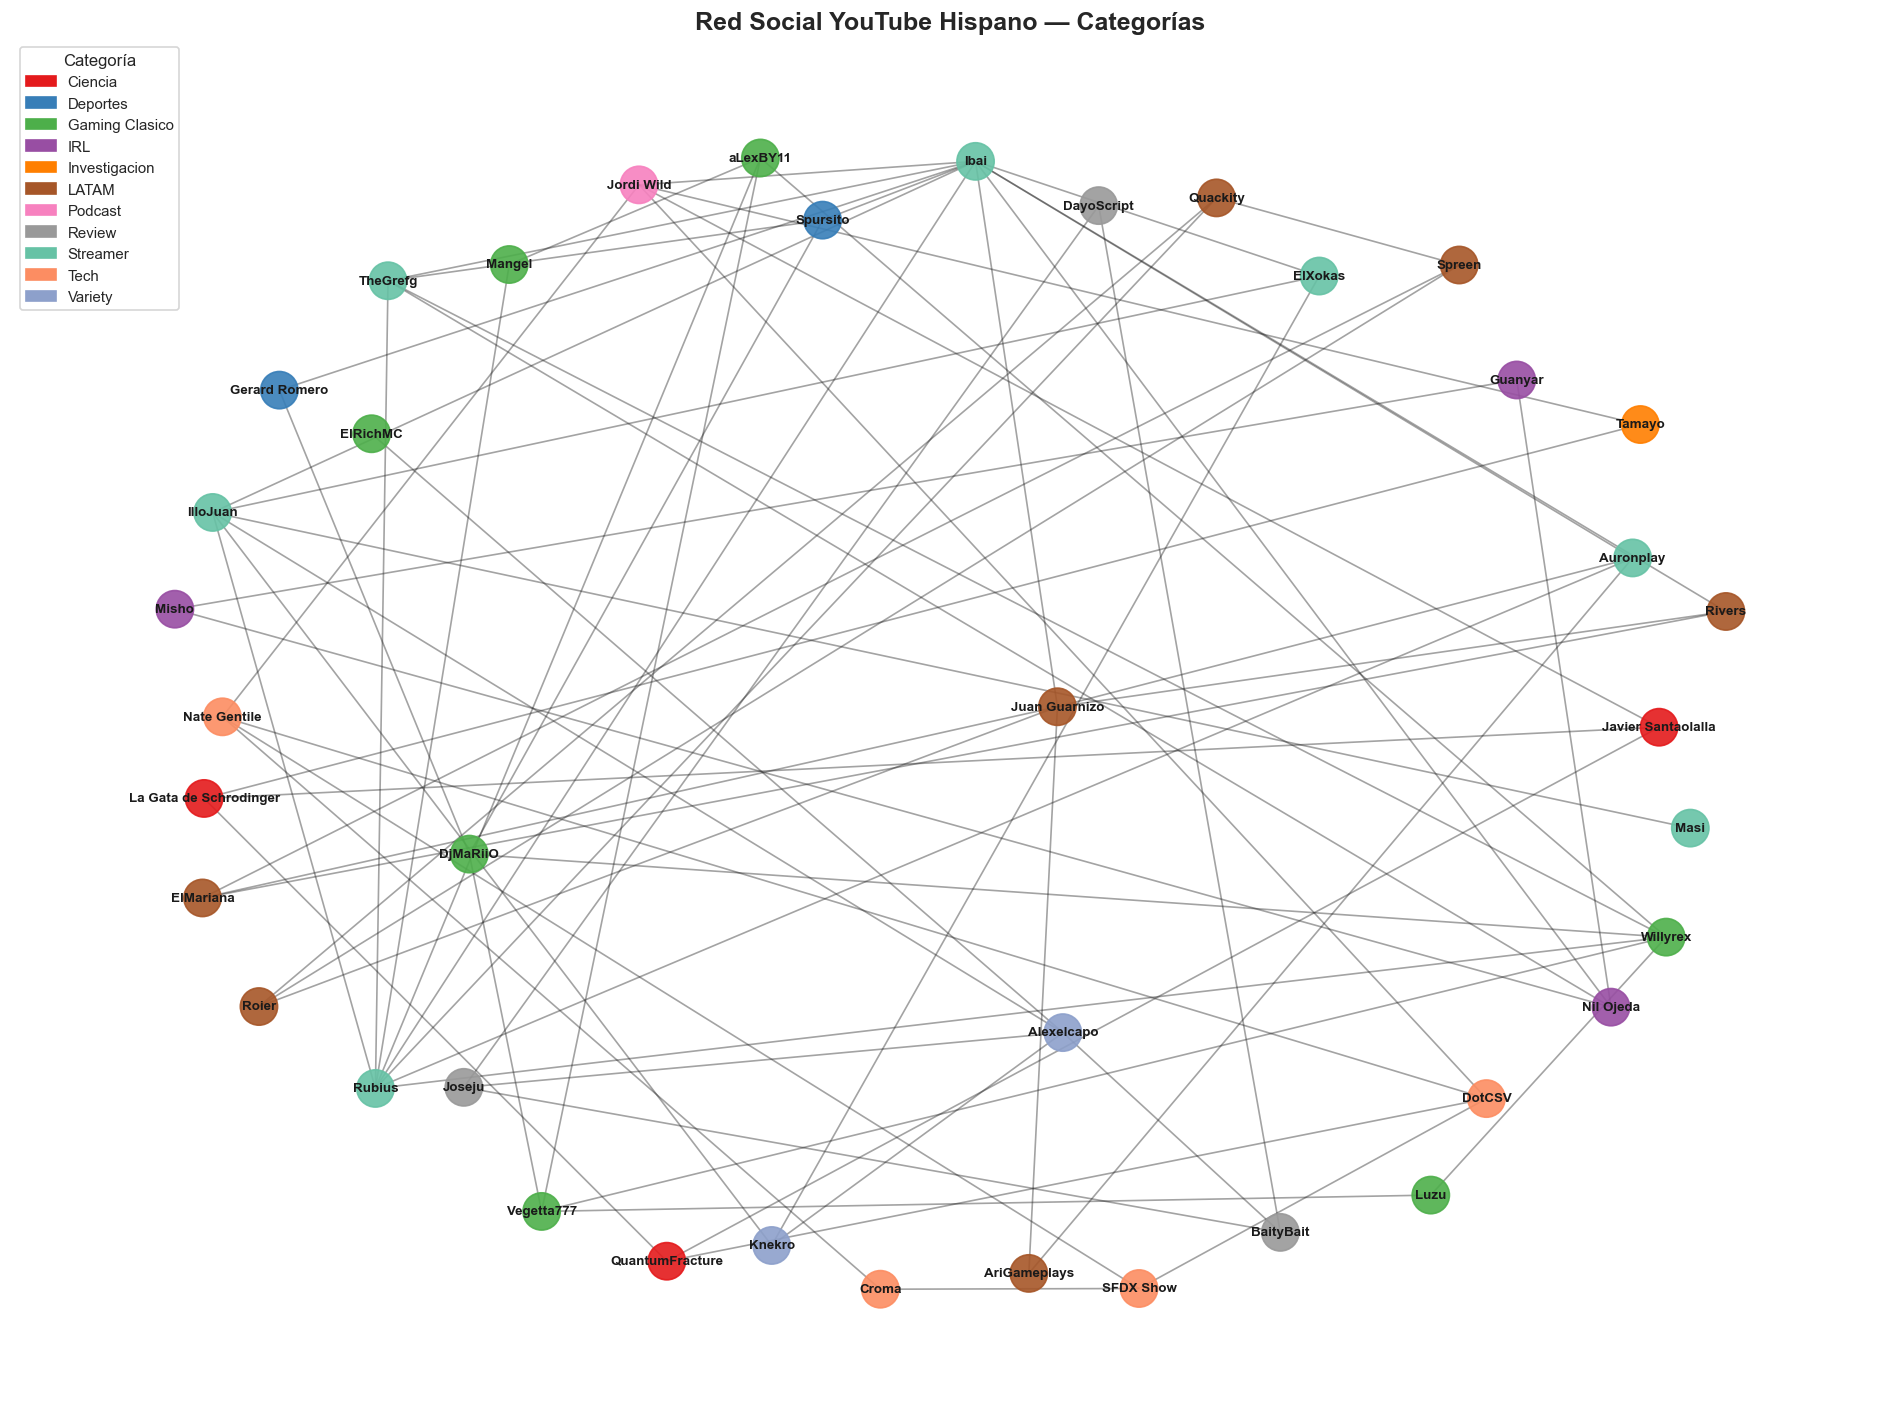

In [480]:
# Visualización principal (categorías)
pos = nx.spring_layout(G, seed=42, k=2.5)

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)

ax.legend(handles=legend_patches, loc="upper left", title="Categoría", fontsize=9, title_fontsize=10)
ax.set_title("Red Social YouTube Hispano — Categorías", fontsize=15, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("red_categorias.png", bbox_inches="tight")
plt.show()

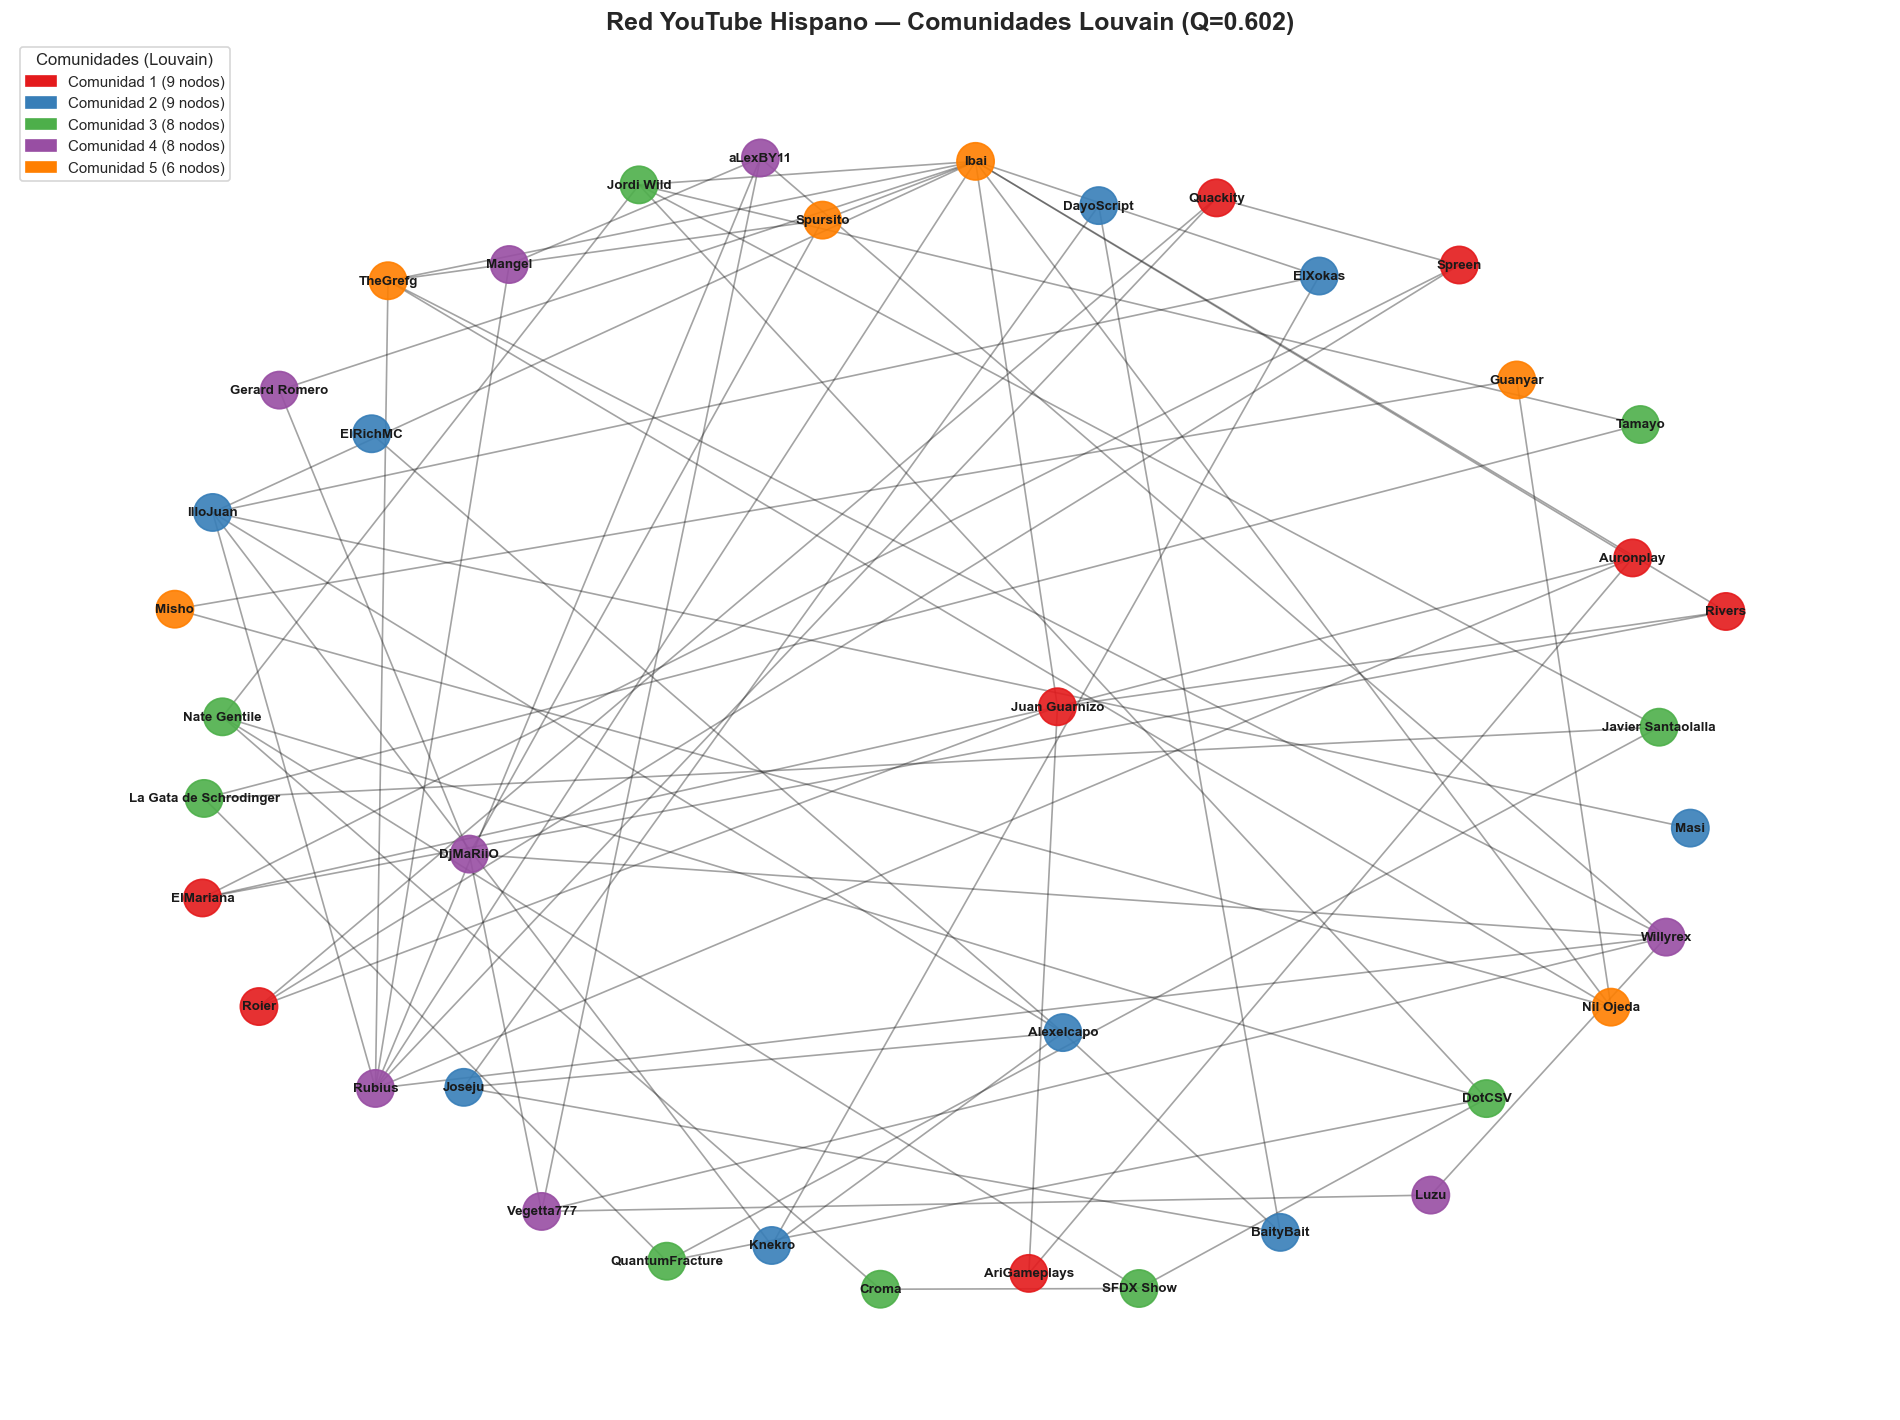

In [481]:
# Visualización con comunidades Louvain
community_colors_list = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
    "#ff7f00", "#a65628", "#f781bf", "#999999",
]

node_community_color = {}
for i, com in enumerate(comunidades_louvain):
    for node in com:
        node_community_color[node] = community_colors_list[i % len(community_colors_list)]

com_colors = [node_community_color[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=com_colors, node_size=500, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)

com_patches = [mpatches.Patch(color=community_colors_list[i], label=f"Comunidad {i+1} ({len(com)} nodos)")
               for i, com in enumerate(sorted(comunidades_louvain, key=len, reverse=True))]
ax.legend(handles=com_patches, loc="upper left", title="Comunidades (Louvain)", fontsize=9, title_fontsize=10)
ax.set_title(f"Red YouTube Hispano — Comunidades Louvain (Q={mod_louvain:.3f})", fontsize=15, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("red_comunidades.png", bbox_inches="tight")
plt.show()

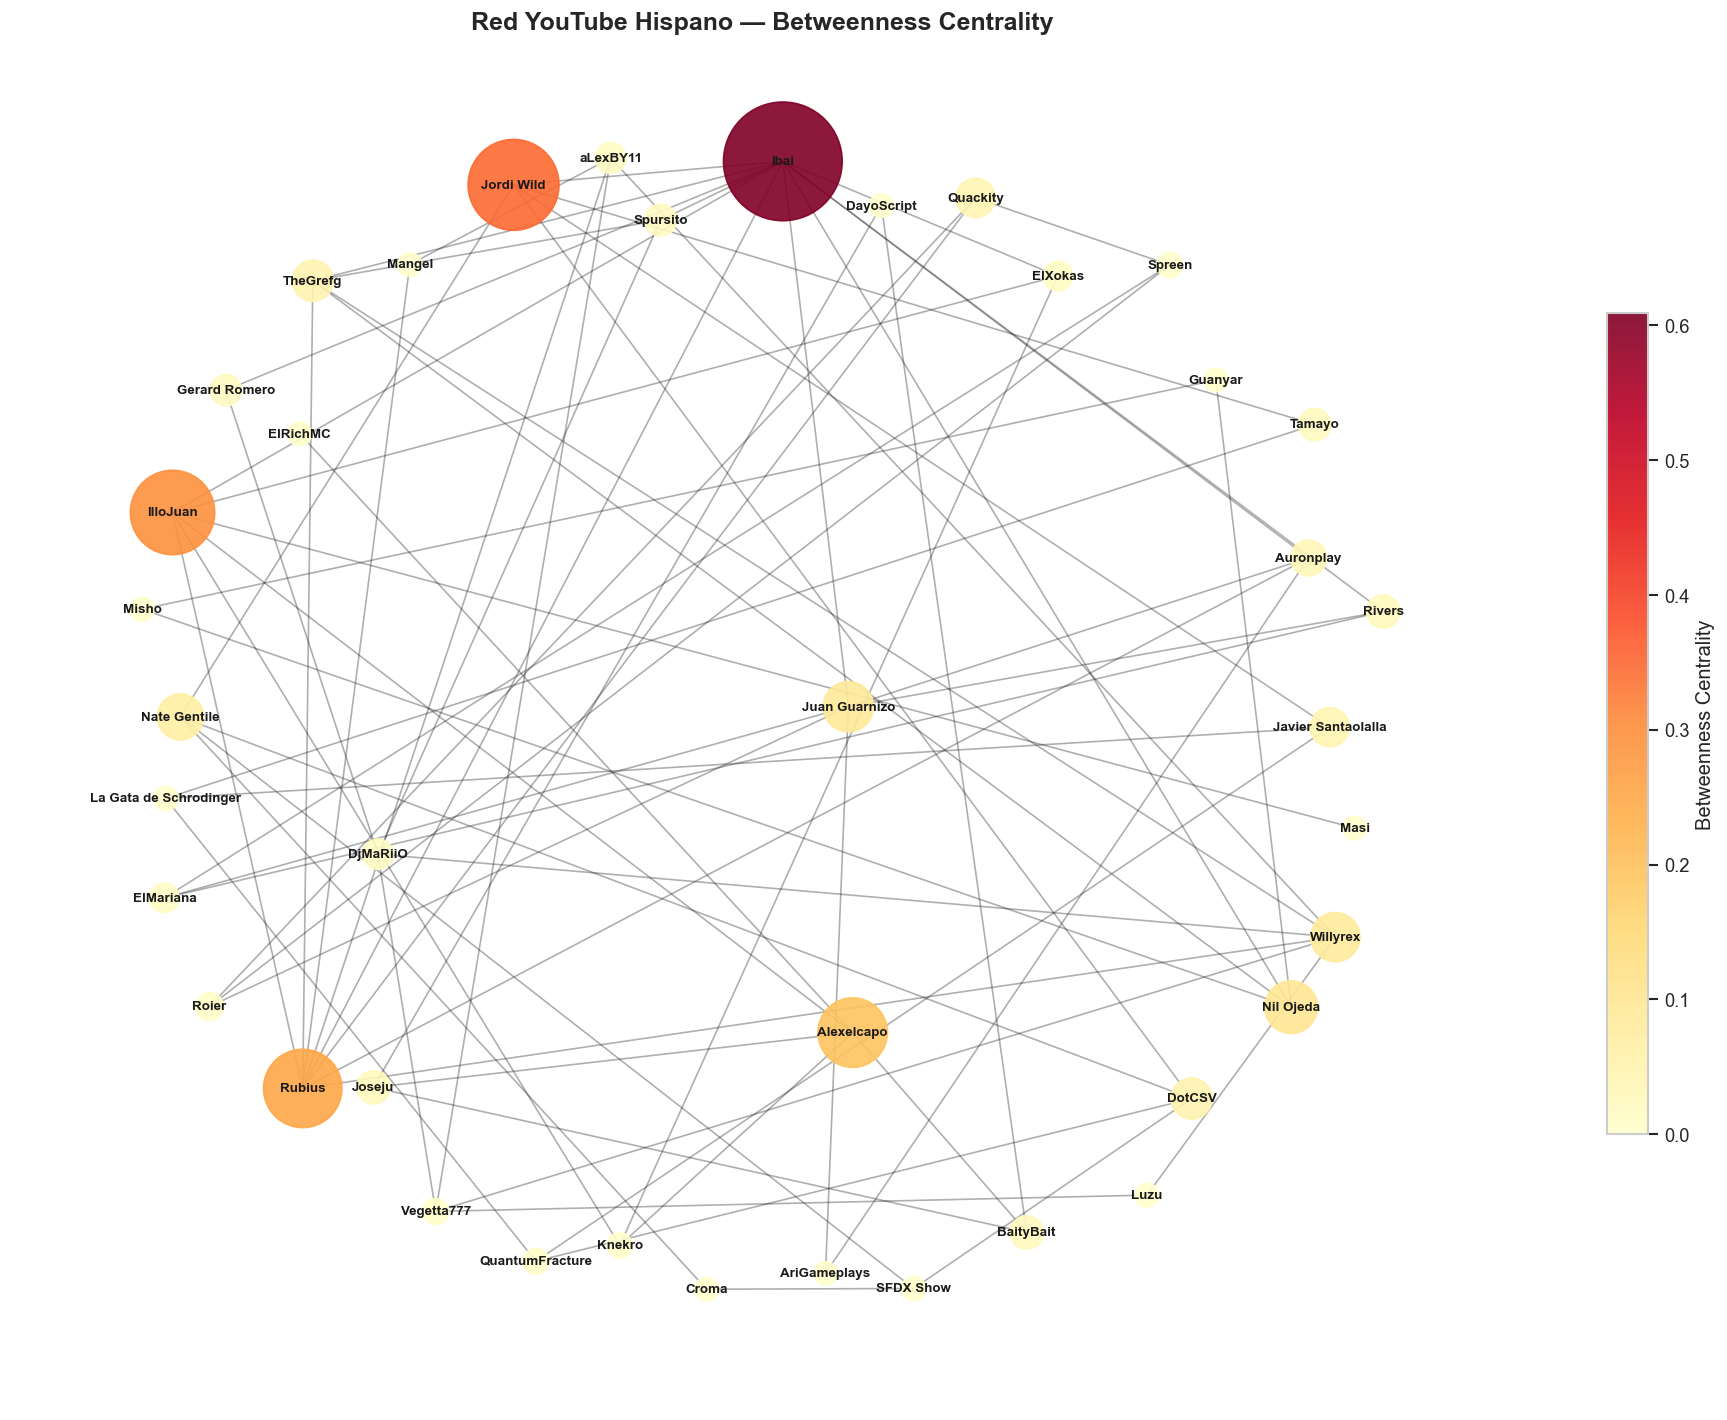

In [482]:
# Visualización con betweenness centrality
betweenness_vals = np.array([betweenness[n] for n in G.nodes()])
node_sizes_betw = 200 + betweenness_vals * 8000

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(G, pos, alpha=0.35, ax=ax)
sc = nx.draw_networkx_nodes(G, pos, node_color=betweenness_vals, node_size=node_sizes_betw,
                             cmap=plt.cm.YlOrRd, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)

plt.colorbar(sc, ax=ax, label="Betweenness Centrality", shrink=0.6)
ax.set_title("Red YouTube Hispano — Betweenness Centrality", fontsize=15, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("red_betweenness.png", bbox_inches="tight")
plt.show()

## 7. Tabla resumen final y análisis de nodos importantes

In [483]:
# Tabla resumen completa con ranking
df_final = df_centralidad.copy()

# Ranking compuesto (promedio de rankings normalizados)
for col in ["Betweenness", "Degree Cent."]:
    df_final[f"rank_{col}"] = df_final[col].rank(ascending=False)

rank_cols = [c for c in df_final.columns if c.startswith("rank_")]
df_final["Ranking Compuesto"] = df_final[rank_cols].mean(axis=1)
df_final = df_final.drop(columns=rank_cols)
df_final = df_final.sort_values("Ranking Compuesto").reset_index(drop=True)
df_final.index += 1

print("TABLA FINAL — NODOS ORDENADOS POR IMPORTANCIA COMPUESTA:")
print(df_final[["Nodo", "Categoría", "Grado", "Betweenness", "Degree Cent.",
                "Clustering", "Ranking Compuesto"]].to_string())

TABLA FINAL — NODOS ORDENADOS POR IMPORTANCIA COMPUESTA:
                      Nodo       Categoría  Grado  Betweenness  Degree Cent.  Clustering  Ranking Compuesto
1                     Ibai        Streamer     11       0.6090        0.2821      0.1455               1.00
2                   Rubius        Streamer      8       0.2513        0.2051      0.2143               3.00
3                 IlloJuan        Streamer      6       0.2953        0.1538      0.2667               3.50
4               Jordi Wild         Podcast      5       0.3466        0.1282      0.1000               4.50
5            Juan Guarnizo           LATAM      6       0.0888        0.1538      0.2667               5.50
6               Alexelcapo         Variety      5       0.1930        0.1282      0.2000               6.00
7                 Willyrex  Gaming Clasico      6       0.0844        0.1538      0.3333               6.00
8                Nil Ojeda             IRL      4       0.0999        0.1026   

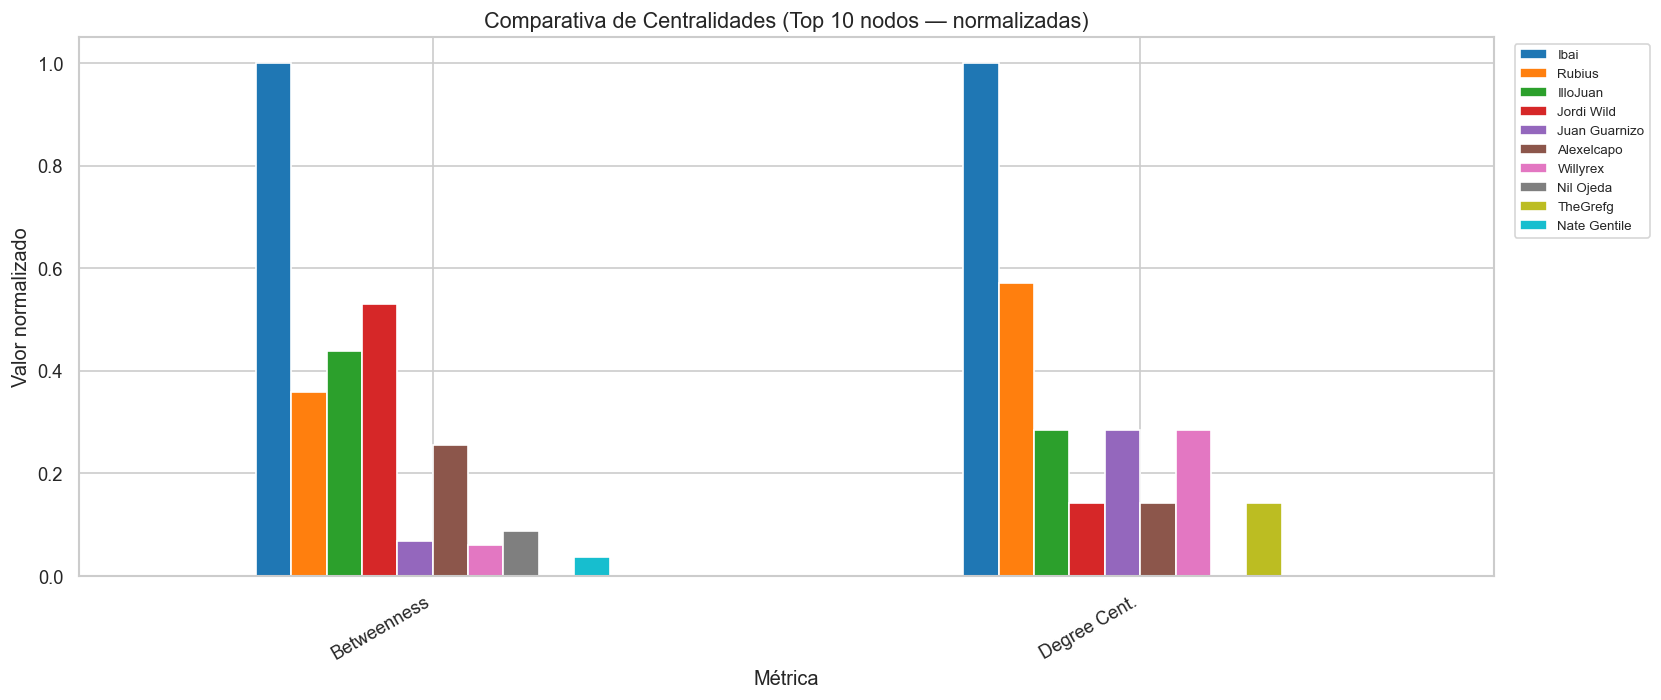

In [484]:
# Visualización comparativa de centralidades (top 10)
top10 = df_final.head(10)["Nodo"].tolist()

metricas_plot = ["Betweenness", "Degree Cent."]
df_top = df_final[df_final["Nodo"].isin(top10)].set_index("Nodo")[metricas_plot]

# Normalizar para comparación visual
df_norm = (df_top - df_top.min()) / (df_top.max() - df_top.min() + 1e-9)

fig, ax = plt.subplots(figsize=(14, 6))
df_norm.T.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Comparativa de Centralidades (Top 10 nodos — normalizadas)", fontsize=13)
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor normalizado")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("comparativa_centralidades.png", bbox_inches="tight")
plt.show()